In [1]:
# --- Figure 2 notebook header ---
import sys, pickle
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists():
        sys.path.insert(0, str(p)); REPO = p; break
import utils
utils.frontiers_style()

cache = REPO / "cache"
with open(cache / "meta.pkl", "rb") as f:
    meta = pickle.load(f)
file_names   = meta["file_names"]
problem_type = meta["problem_type"]
scores       = meta["scores"]
with open(cache / "out_agg.pkl", "rb") as f:
    out_agg = pickle.load(f)

basic_info = utils.load_basic_info()
clf, reg = utils.split_problem_lists(file_names, basic_info)
print(f"loaded: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg | out_agg for {len(out_agg)} tasks")

loaded: 31 tasks | 14 clf | 17 reg | out_agg for 31 tasks


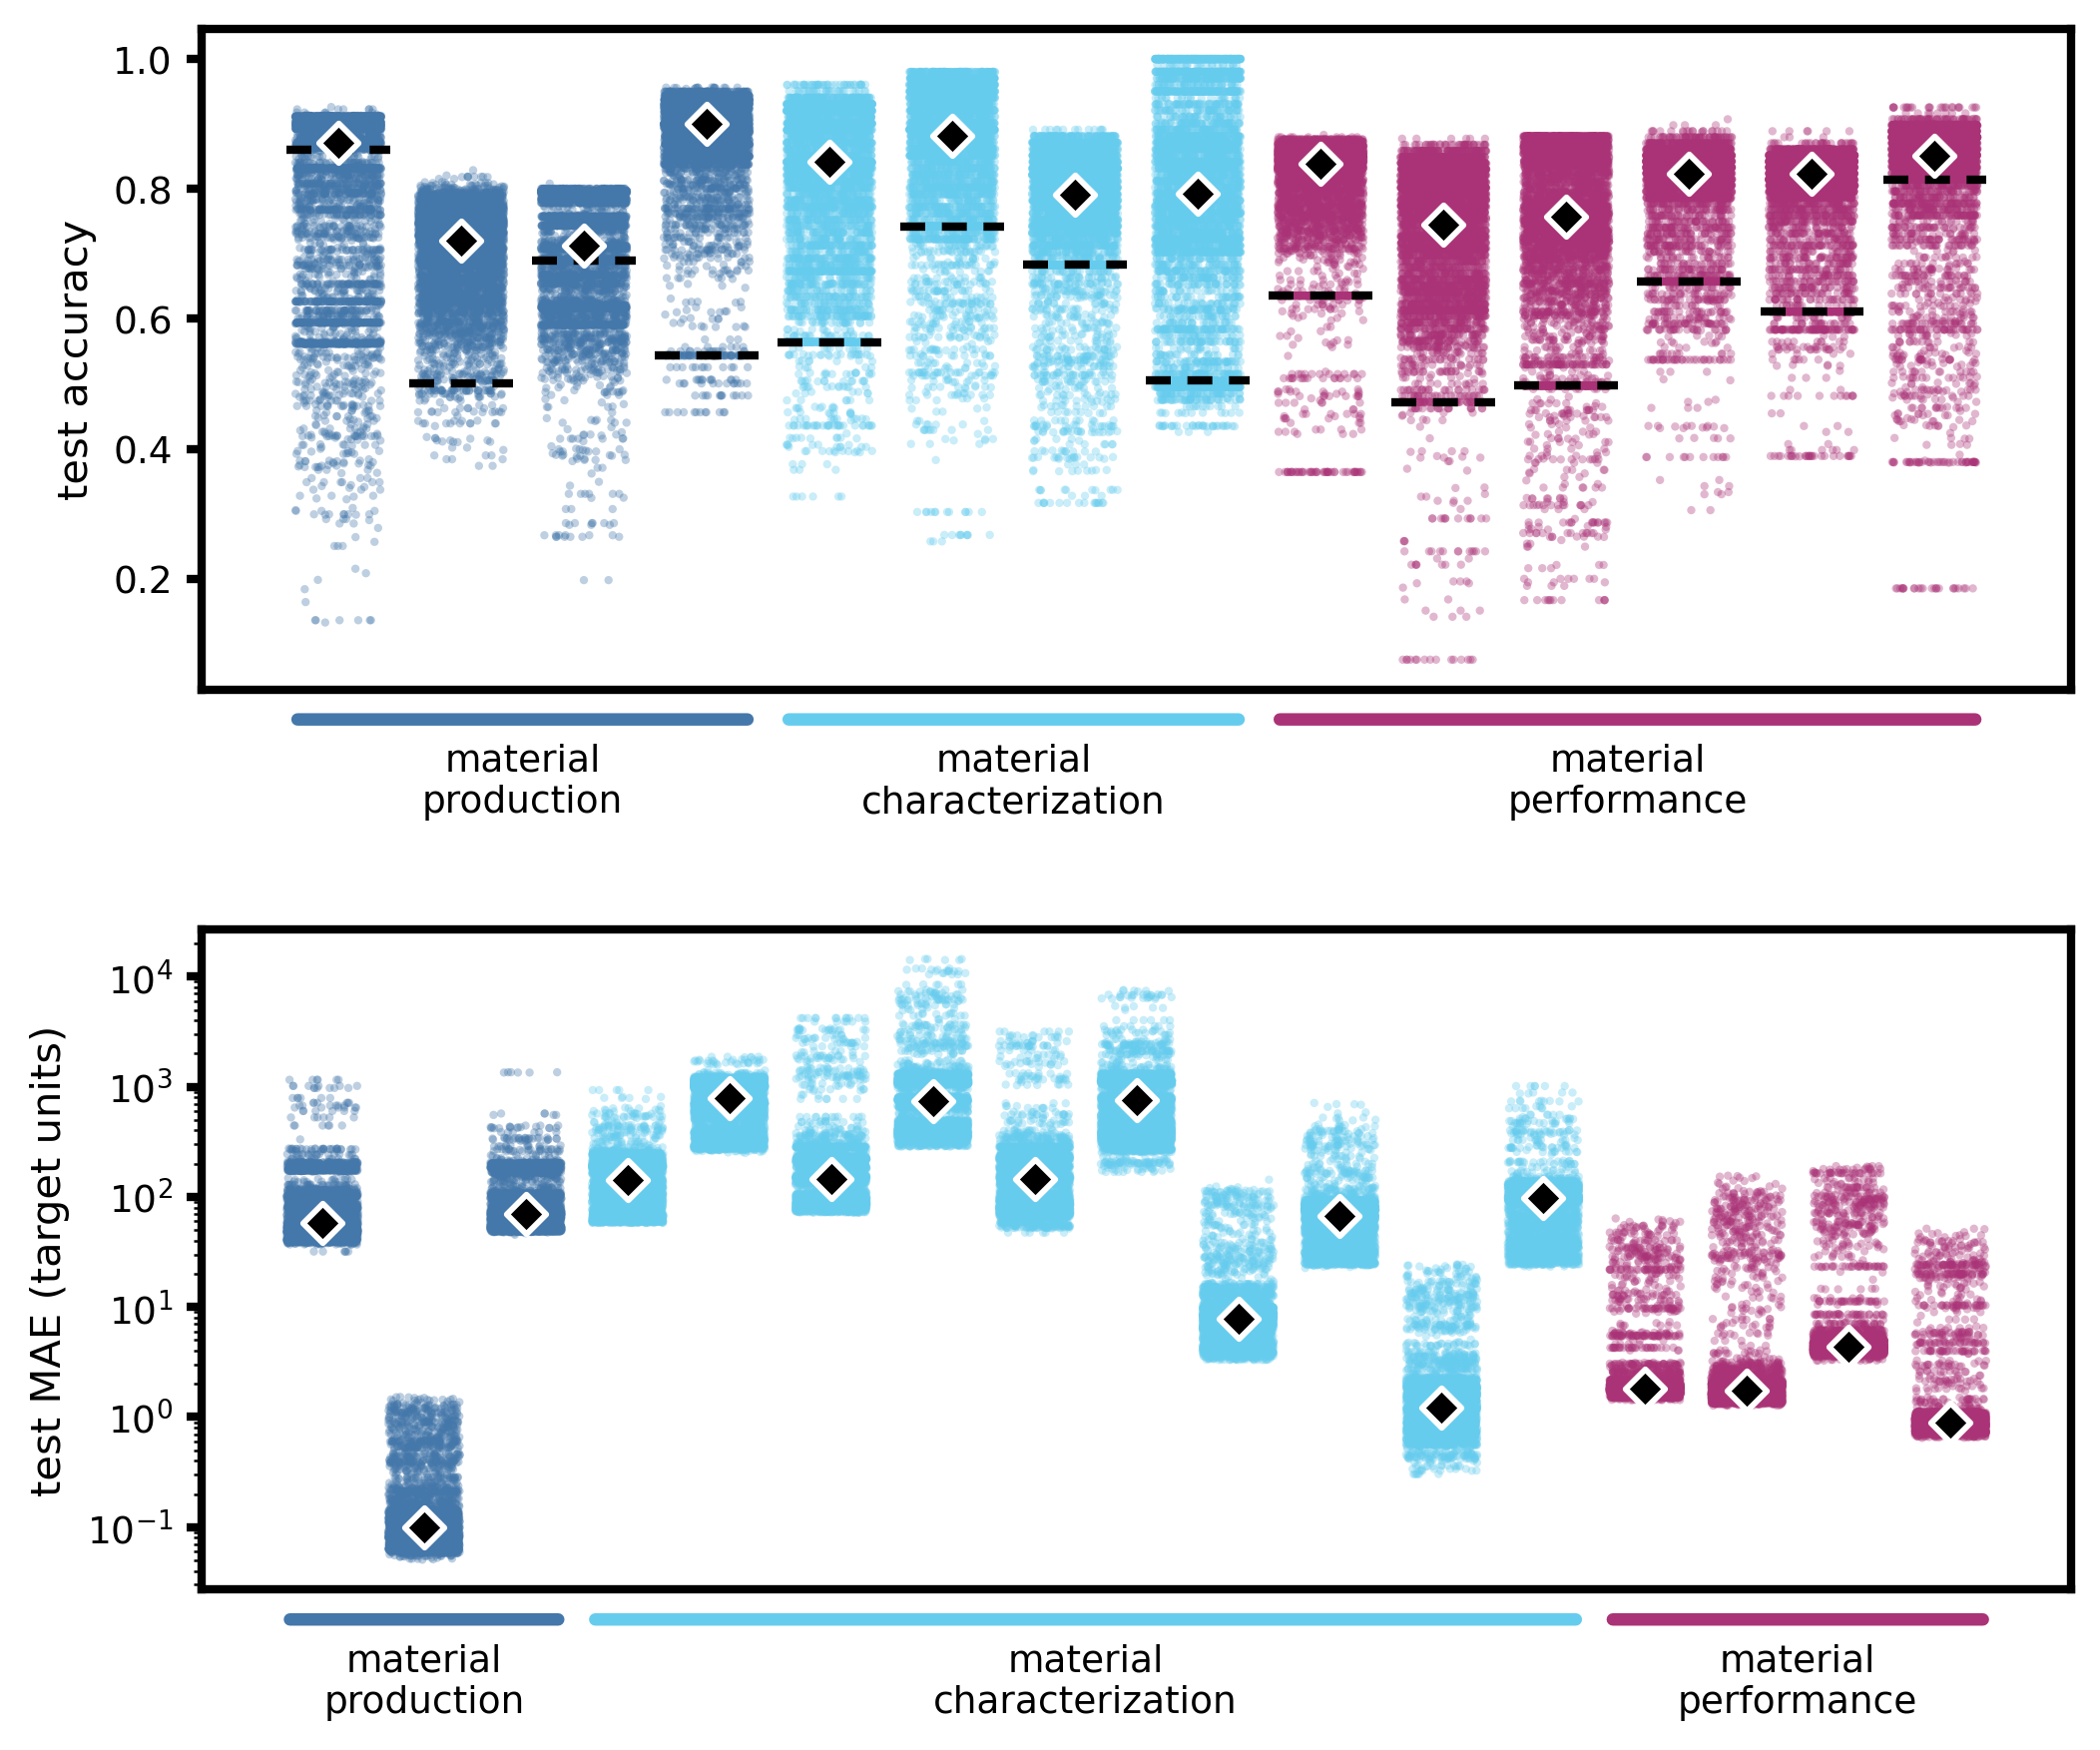

In [43]:
import seaborn as sns
from matplotlib.lines import Line2D

# vivid but colorblind-safe (blue / orange / purple — avoids red-green)
# domain_palette = {'production':'#1f77b4', 'characterization':'#ff7f0e',
#                   'performance':'#9467bd', 'other':'#999999'}
domain_palette = {'production':'#4477AA', 'characterization':'#66CCEE',
                  'performance':'#AA3377', 'other':'#999999'}


plt.rcParams.update({
    'axes.linewidth': 2.0,               # >= 2pt lines (spec)
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'xtick.major.width': 2.0, 'ytick.major.width': 2.0,   # >= 2pt
    'pdf.fonttype': 42, 'ps.fonttype': 42,                 # editable text in vector export
})

DOMAIN_ORDER = {'production':0, 'characterization':1, 'performance':2, 'other':3}
dsort = lambda t: sorted(t, key=lambda x: (DOMAIN_ORDER[DOMAIN[x]], x))
order_clf, order_reg = dsort(clf), dsort(reg)

# 180 mm wide; height chosen so it stays within one page and data isn't stretched
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(180/25.4, 150/25.4))

def panel(ax, df, order, ycol, medians, baseline=None):
    sns.stripplot(data=df, x='task', y=ycol, ax=ax, order=order,
                  size=2, alpha=0.35, jitter=0.35, hue='domain',
                  palette=domain_palette, legend=False)
    for i, t in enumerate(order):
        if baseline is not None:
            ax.hlines(baseline[t], i-0.42, i+0.42, color='black',
                      linewidth=2.0, linestyle=(0,(3,2)), zorder=8)
        ax.scatter(i, medians[t], marker='D', s=45, color='black',
                   edgecolor='white', linewidth=1.4, zorder=10)
    ax.set_xticks(range(len(order))); ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0); ax.set_xlabel('')

    doms = [DOMAIN[t] for t in order]
    lbl = {'production':'material\nproduction', 'characterization':'material\ncharacterization',
           'performance':'material\nperformance'}
    BRACKET_Y = -0.045      # bracket sits further below the axis (was -0.015)
    LABEL_Y   = -0.08      # labels sit below the bracket with a gap (was -0.02)
    for d in ['production','characterization','performance']:
        idxs = [i for i,dd in enumerate(doms) if dd==d]
        if not idxs: continue
        c = (min(idxs)+max(idxs))/2
        col = domain_palette[d]                    # match the datapoint color
        ax.annotate(lbl[d], xy=(c, LABEL_Y), xycoords=('data','axes fraction'),
                    ha='center', va='top', fontsize=9, color='black',
                    annotation_clip=False)
        ax.annotate('', xy=(min(idxs)-0.4, BRACKET_Y), xytext=(max(idxs)+0.4, BRACKET_Y),
                    xycoords=('data','axes fraction'),
                    arrowprops=dict(arrowstyle='-', lw=3.0, color=col),
                    annotation_clip=False)


maj = {t: basic_info.loc[basic_info['File_name']==t, 'Majority_class'].iloc[0] for t in order_clf}
panel(ax0, df_clf, order_clf, 'mean_accuracy', med_acc, baseline=maj)
ax0.set_ylabel('test accuracy')          # unitless, bounded 0-1

panel(ax1, df_reg, order_reg, 'mean_MAE', med_mae)
ax1.set_yscale('log')
ax1.set_ylabel('test MAE (target units)')   # units noted per spec

fig.tight_layout(h_pad=3.0)

In [44]:
from pathlib import Path
figdir = REPO / "figures"; figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "Figure2_landscape.pdf", dpi=300, bbox_inches='tight')
fig.savefig(figdir / "Figure2_landscape.png", dpi=300, bbox_inches='tight')  # for quick viewing
print("saved to", figdir)

saved to C:\Users\conno\Documents\GitHub\ML_MetaLearning_SoftMatter\figures
